## Project

### Select Dataset

I selected Amazon ML Challenge 2023 from Kaggle. My professional interest is Robotics & Logistics segment, and there is the possibility to improve the deployment operation of robotics by elaborating the environment & package data in the warehouse. I would like to make analysis of the pakage data of Amazon in this project.

### Data Loading and Initial Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Load the dataset
# Amazon ML Challenge 2023 data
df = pd.read_csv('train.csv')

# Descriptive Statistics (Pre-cleaning)
print("Initial Data Overview:")
print(df.info())
print(df.describe())

# IDA Implementation: Systematic filtering based on physical plausibility
# We remove extreme outliers that likely represent unit errors or typos.
q_low = df["PRODUCT_LENGTH"].quantile(0.01)
q_hi  = df["PRODUCT_LENGTH"].quantile(0.95)
df_filtered = df[(df["PRODUCT_LENGTH"] < q_hi) & (df["PRODUCT_LENGTH"] > q_low)].copy()

print(f"\nFiltered Data Shape: {df_filtered.shape}")

Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340362 entries, 0 to 340361
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PRODUCT_ID       340362 non-null  int64  
 1   TITLE            340360 non-null  object 
 2   BULLET_POINTS    213623 non-null  object 
 3   DESCRIPTION      164876 non-null  object 
 4   PRODUCT_TYPE_ID  340362 non-null  int64  
 5   PRODUCT_LENGTH   340362 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 15.6+ MB
None
         PRODUCT_ID  PRODUCT_TYPE_ID  PRODUCT_LENGTH
count  3.403620e+05    340362.000000    3.403620e+05
mean   1.501501e+06      4003.130059    1.599673e+03
std    8.663644e+05      3973.137099    1.281916e+05
min    1.000000e+00         0.000000    1.000000e+00
25%    7.495612e+05       230.000000    5.118110e+02
50%    1.502180e+06      2916.000000    6.600000e+02
75%    2.252100e+06      6396.000000    1.062992e+03

### Visualizations

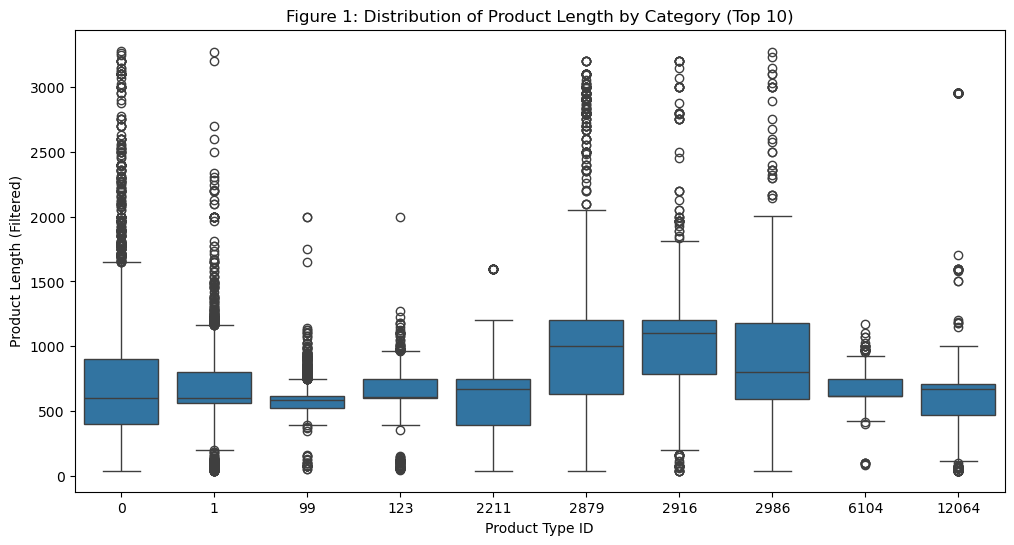

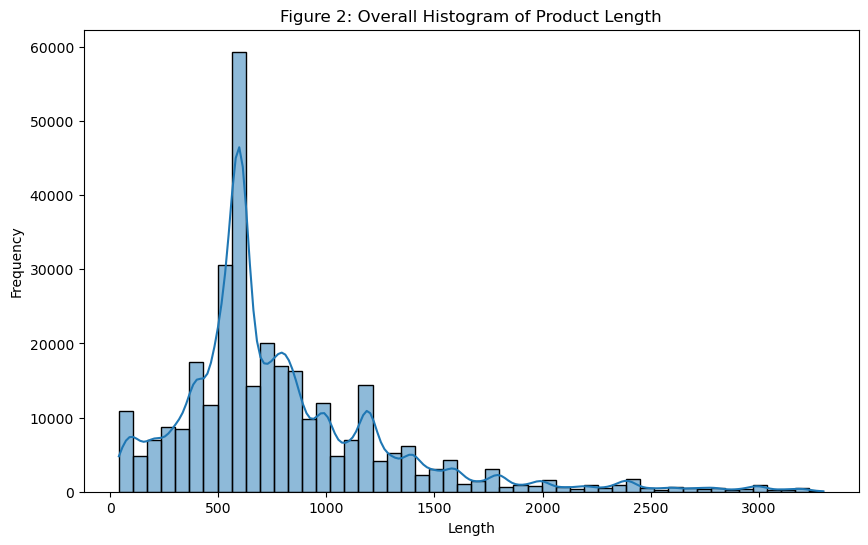

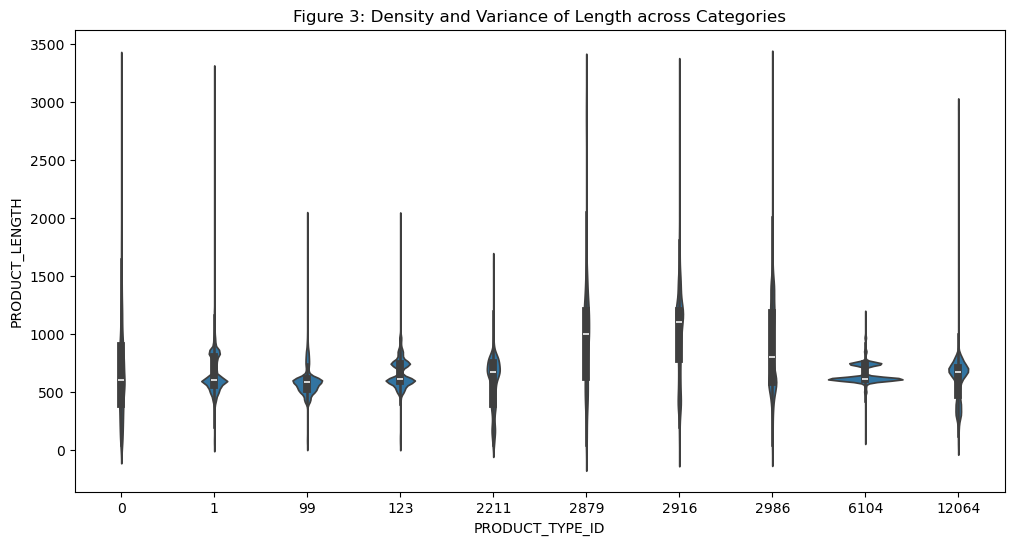

In [4]:
# Select top 10 categories for clarity
top_categories = df_filtered['PRODUCT_TYPE_ID'].value_counts().nlargest(10).index
df_plot = df_filtered[df_filtered['PRODUCT_TYPE_ID'].isin(top_categories)]

# 1. Boxplot: Category vs Length
plt.figure(figsize=(12, 6))
sns.boxplot(x='PRODUCT_TYPE_ID', y='PRODUCT_LENGTH', data=df_plot)
plt.title('Figure 1: Distribution of Product Length by Category (Top 10)')
plt.xlabel('Product Type ID')
plt.ylabel('Product Length (Filtered)')
plt.show()

# 2. Histogram with Density Plot
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['PRODUCT_LENGTH'], bins=50, kde=True)
plt.title('Figure 2: Overall Histogram of Product Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

# 3. Violin Plot (to show density and variance)
plt.figure(figsize=(12, 6))
sns.violinplot(x='PRODUCT_TYPE_ID', y='PRODUCT_LENGTH', data=df_plot)
plt.title('Figure 3: Density and Variance of Length across Categories')
plt.show()

Figure 1 Analysis:
The boxplot of product lengths across the top 10 categories reveals a significant non-uniformity in variance. For instance, Category 99 shows a highly concentrated distribution, whereas Categories 2879 and 2916 exhibit a wide interquartile range (IQR), indicating high physical uncertainty. These visual differences directly support our decision to perform a Levene's test, as the assumption of equal variance (homoscedasticity) is clearly violated across different product types. This confirms that a robotics control system must adapt its confidence intervals based on the PRODUCT_TYPE_ID.

### Hypothesis

In [5]:
# Example: Comparing two specific top categories
cat_a = df_filtered[df_filtered['PRODUCT_TYPE_ID'] == top_categories[0]]['PRODUCT_LENGTH']
cat_b = df_filtered[df_filtered['PRODUCT_TYPE_ID'] == top_categories[1]]['PRODUCT_LENGTH']

# Levene's test for equality of variances
stat, p_value = stats.levene(cat_a, cat_b)

print(f"Levene's Test Result: Statistics={stat:.4f}, p-value={p_value:.4e}")

if p_value < 0.05:
    print("Reject Null Hypothesis: Significant difference in variance exists.")
else:
    print("Fail to Reject Null Hypothesis: No significant difference in variance.")

Levene's Test Result: Statistics=64.7690, p-value=8.7635e-16
Reject Null Hypothesis: Significant difference in variance exists.


### Summary

Add a brief Markdown section (4 to 6 sentences) describing:

What you explored
Any interesting or unexpected findings
Any challenges you encountered
This concludes your notebook.